In [1]:
import pandas as pd
import numpy as np
import ast
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA
import plotly.express as px
from sklearn.preprocessing import StandardScaler
import _pickle as cPickle
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [2]:
# FEATURES
features = [
    "duration",
    "login_attempts",
    "num_commands",
    "file_download",
    "commands_per_second",
    "unique_commands",
    "avg_command_length",
    "auth_severity_score"
]

# LOAD
dataset = pd.read_csv("../log/dataset.csv")

# FIX labels 
dataset["attack_type"] = dataset["attack_type"].apply(ast.literal_eval)

# FEATURES
X = dataset[features].fillna(0)

#RUIDO
np.random.seed(42)
X["commands_per_second"] += np.random.normal(0, 0.05, len(X))
X["duration"] += np.random.normal(0, 0.5, len(X))

# MULTILABEL ENCODING
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(dataset["attack_type"])

# SPLIT 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# MODEL
base_model = RandomForestClassifier(
    n_estimators=150,
    random_state=42
)

model = MultiOutputClassifier(base_model)
model.fit(X_train, y_train)


with open('../model/model.pickle', 'wb') as f:
    cPickle.dump(model, f)

# PREDICT
y_pred = model.predict(X_test)

# REPORT
print(classification_report(
    y_test,
    y_pred,
    target_names=mlb.classes_,
    zero_division=0
))

                        precision    recall  f1-score   support

auth_success_no_action       1.00      0.99      1.00       169
             execution       0.00      0.00      0.00         0
         file_activity       0.00      0.00      0.00         0
    high_auth_pressure       0.99      1.00      0.99        81
    interactive_attack       0.00      0.00      0.00         0
      malware_download       1.00      1.00      1.00         2
           persistence       0.00      0.00      0.00         0
      privilege_change       0.00      0.00      0.00         1
        reconnaissance       1.00      0.88      0.93         8
         scan_or_noise       1.00      1.00      1.00       250

             micro avg       1.00      0.99      1.00       511
             macro avg       0.50      0.49      0.49       511
          weighted avg       1.00      0.99      1.00       511
           samples avg       0.97      0.97      0.97       511



In [3]:
scaler = StandardScaler()

data_scaled = scaler.fit(dataset[["duration","login_attempts","num_commands","file_download","recon","download","chmod","execution","persistence","commands_per_second"]])
X = np.array(dataset[["duration","login_attempts","num_commands","file_download","recon","download","chmod","execution","persistence","commands_per_second"]])
pca = PCA(n_components=2)
kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto").fit(X)
kmeans.fit(X)
y_means = kmeans.predict(X)
pca_results = pca.fit_transform(X)

fig = px.scatter(pca_results,x=0,y=1,color=y_means)
fig.show()

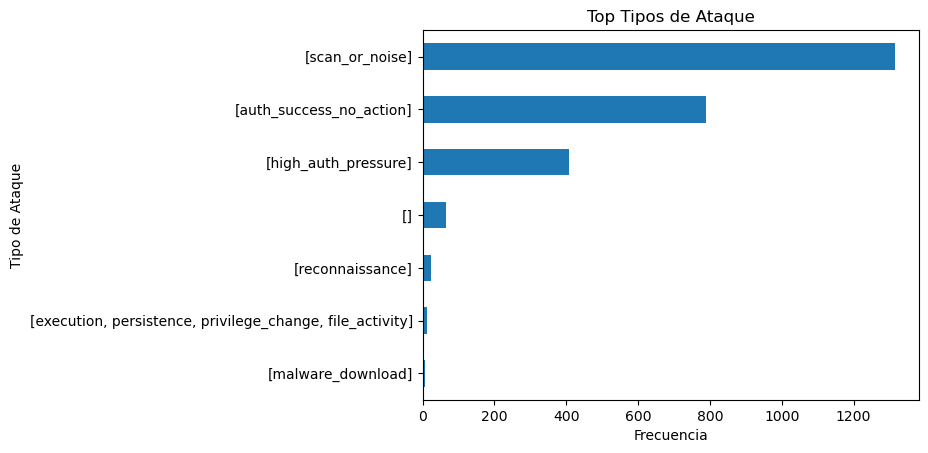

attack_type
[scan_or_noise]                                              1315
[auth_success_no_action]                                      790
[high_auth_pressure]                                          407
[]                                                             65
[reconnaissance]                                               23
[execution, persistence, privilege_change, file_activity]      13
[malware_download]                                              6
Name: count, dtype: int64


In [4]:
# Representación de la frecuencia de nombres de usuarios utilizados por los intrusos.
ataques = dataset["attack_type"]
top_users = ataques.value_counts().head(7)  # Top 7

top_users.sort_values().plot(kind="barh")

plt.title("Top Tipos de Ataque")
plt.xlabel("Frecuencia")
plt.ylabel("Tipo de Ataque")

plt.show()

print(top_users)